# Entraînement YOLO - Détection de déchets

Ce notebook couvre tout le pipeline : préparation des données, audit, nettoyage, entraînement, comparaison et rapport final.

## Sommaire

1. Environnement et imports
2. Téléchargement et préparation des données
3. Audit du dataset
4. Nettoyage / fusion des classes
5. Préparation GPU et ressources
6. Entraînement des modèles
7. Analyse des résultats
8. Rapport final automatique

In [ ]:
import os
import re
import sys
import shutil
import subprocess
import textwrap
from datetime import datetime
from pathlib import Path
from collections import Counter, defaultdict
from textwrap import dedent
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import psutil
import ultralytics
from ultralytics import YOLO
from IPython.display import Image, display
from IPython import get_ipython

### Vérification de l’environnement Ultralytics

Cette cellule vérifie les versions et la compatibilité de l’environnement d’exécution pour YOLO.

In [10]:
ultralytics.checks()

Ultralytics 8.4.25 🚀 Python-3.10.19 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
Setup complete ✅ (20 CPUs, 15.5 GB RAM, 138.8/1006.9 GB disk)


## 2) Téléchargement et préparation des données

On récupère le dataset puis on prépare le fichier `data.yaml` utilisé par YOLO.

### Téléchargement du dataset (Kaggle)

Télécharge et décompresse le dataset source dans le dossier local `dataset/`.

In [ ]:
os.environ['KAGGLE_USERNAME'] = "antoinemilochevitch"
os.environ['KAGGLE_KEY'] = "KGAT_4811baf31fab92071dd57252ed5e265b"

# Télécharger le dataset
!kaggle datasets download -d spellsharp/garbage-data

# Décompresser le dataset dans un dossier nommé "dataset"
!unzip -q garbage-data.zip -d dataset

### Génération du fichier data.yaml

Construit ou met à jour la configuration YOLO (chemins, nombre de classes, noms des classes).

In [ ]:
base_path = '/home/antoine/utbm/wall_e_train/dataset/YOLO-Waste-Detection-1/YOLO-Waste-Detection-1'

data_yaml = {
    'path': base_path,
    'train': 'train/images',
    'val': 'valid/images',  
    'test': 'test/images',
    'nc': 44,
    'names': [
        'Aerosols', 'Aluminum can', 'Aluminum caps', 'Cardboard', 'Cellulose', 
        'Ceramic', 'Combined plastic', 'Container for household chemicals', 
        'Disposable tableware', 'Electronics', 'Foil', 'Furniture', 'Glass bottle', 
        'Iron utensils', 'Liquid', 'Metal shavings', 'Milk bottle', 'Organic', 
        'Paper bag', 'Paper cups', 'Paper shavings', 'Paper', 'Papier mache', 
        'Plastic bag', 'Plastic bottle', 'Plastic can', 'Plastic canister', 
        'Plastic caps', 'Plastic cup', 'Plastic shaker', 'Plastic shavings', 
        'Plastic toys', 'Postal packaging', 'Printing industry', 'Scrap metal', 
        'Stretch film', 'Tetra pack', 'Textile', 'Tin', 'Unknown plastic', 
        'Wood', 'Zip plastic bag', 'Ramen Cup', 'Food Packet'
    ]
}

yaml_file_path = f'{base_path}/data.yaml'

with open(yaml_file_path, 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=False)

print(f"Fichier mis à jour avec succès : {yaml_file_path}")

## 3) Audit du dataset

Cette section mesure la distribution des classes et génère des artefacts visuels pour détecter les déséquilibres.

### Comptage des labels par classe

Compte les occurrences par classe dans `train` et `valid`, puis sauvegarde un CSV de synthèse.

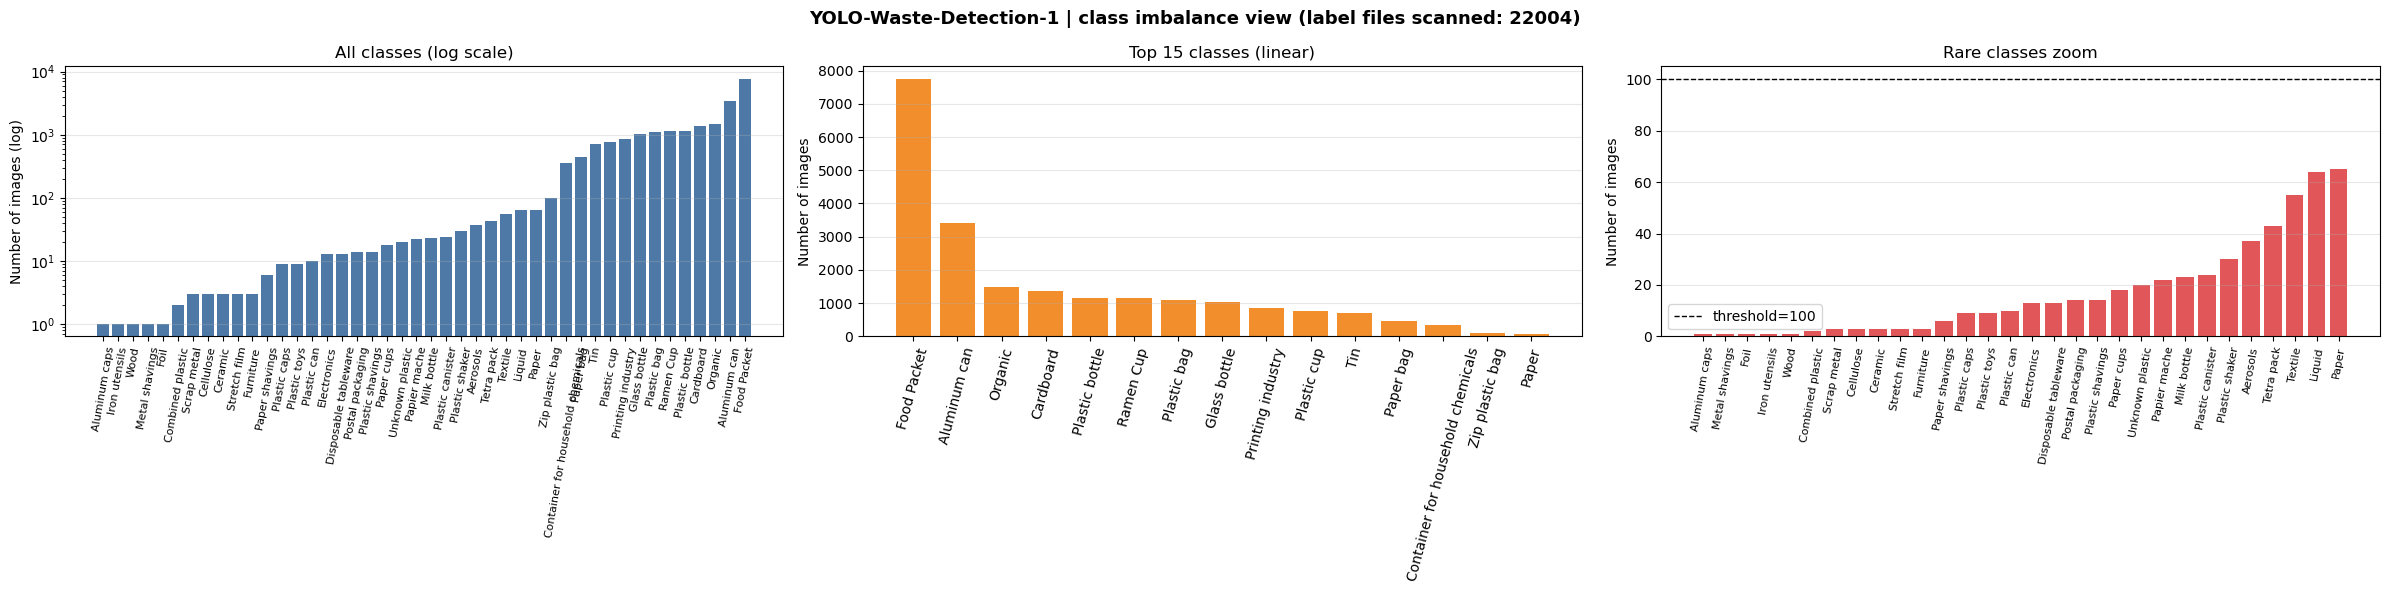


Dataset: /home/antoine/utbm/wall_e_train/dataset/YOLO-Waste-Detection-1/YOLO-Waste-Detection-1
Total classes: 44
Classes <= 100 images: 30
Top 10 classes:
       class_name  image_count
      Food Packet         7741
     Aluminum can         3423
          Organic         1486
        Cardboard         1374
   Plastic bottle         1158
        Ramen Cup         1148
      Plastic bag         1085
     Glass bottle         1031
Printing industry          868
      Plastic cup          763
Bottom 10 classes:
      class_name  image_count
    Stretch film            3
         Ceramic            3
       Cellulose            3
     Scrap metal            3
Combined plastic            2
   Iron utensils            1
            Foil            1
  Metal shavings            1
            Wood            1
   Aluminum caps            1


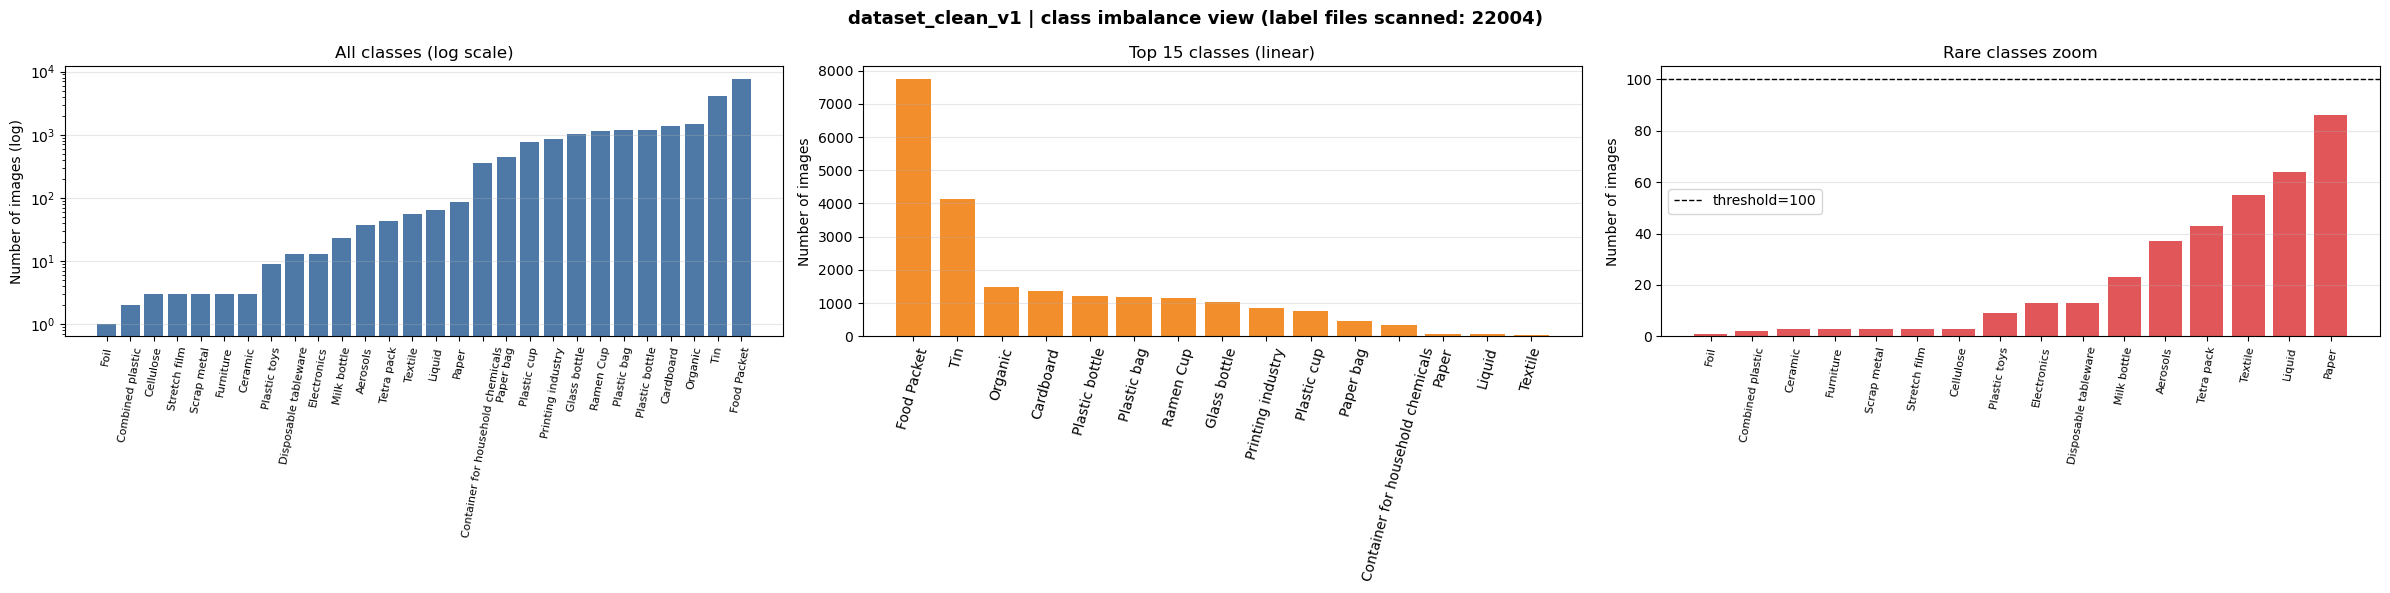


Dataset: /home/antoine/utbm/wall_e_train/dataset/dataset_clean_v1
Total classes: 28
Classes <= 100 images: 16
Top 10 classes:
       class_name  image_count
      Food Packet         7741
              Tin         4126
          Organic         1486
        Cardboard         1374
   Plastic bottle         1204
      Plastic bag         1180
        Ramen Cup         1148
     Glass bottle         1031
Printing industry          868
      Plastic cup          763
Bottom 10 classes:
          class_name  image_count
         Electronics           13
Disposable tableware           13
        Plastic toys            9
             Ceramic            3
           Furniture            3
         Scrap metal            3
        Stretch film            3
           Cellulose            3
    Combined plastic            2
                Foil            1


In [3]:
dataset_yamls = [
    Path('/home/antoine/utbm/wall_e_train/dataset/YOLO-Waste-Detection-1/YOLO-Waste-Detection-1/data.yaml'),
    Path('/home/antoine/utbm/wall_e_train/dataset/dataset_clean_v1/data_clean.yaml'),
]

RARE_THRESHOLD = 100  # adjust if needed

def images_per_class_from_dataset_yaml(yaml_path: Path):
    with yaml_path.open('r', encoding='utf-8') as f:
        cfg = yaml.safe_load(f)

    dataset_root = Path(cfg['path'])
    class_names = cfg['names']

    # Count image-level class presence across splits (one image can contribute to multiple classes)
    counts = Counter()
    scanned_label_files = 0

    for split in ['train', 'valid', 'test']:
        split_labels = dataset_root / split / 'labels'
        if not split_labels.exists():
            continue

        for label_file in split_labels.glob('*.txt'):
            scanned_label_files += 1
            classes_in_image = set()
            with label_file.open('r', encoding='utf-8') as lf:
                for line in lf:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    try:
                        cls_id = int(float(parts[0]))
                        classes_in_image.add(cls_id)
                    except Exception:
                        continue

            for cls_id in classes_in_image:
                if 0 <= cls_id < len(class_names):
                    counts[cls_id] += 1

    rows = [
        {
            'class_id': i,
            'class_name': class_names[i],
            'image_count': counts.get(i, 0),
        }
        for i in range(len(class_names))
    ]

    df_counts = pd.DataFrame(rows)
    df_desc = df_counts.sort_values('image_count', ascending=False).reset_index(drop=True)
    return df_desc, scanned_label_files

valid_datasets = [yml for yml in dataset_yamls if yml.exists()]
for yml in dataset_yamls:
    if not yml.exists():
        print(f'YAML not found, skipped: {yml}')

if not valid_datasets:
    print('No dataset YAML found. Update dataset_yamls paths in this cell.')
else:
    for yml in valid_datasets:
        df_desc, n_files = images_per_class_from_dataset_yaml(yml)
        df_asc = df_desc.sort_values('image_count', ascending=True).reset_index(drop=True)

        rare_df = df_desc[df_desc['image_count'] <= RARE_THRESHOLD].copy()
        if rare_df.empty:
            rare_df = df_desc.tail(min(10, len(df_desc))).copy()

        top_n = min(15, len(df_desc))
        top_df = df_desc.head(top_n).copy()

        fig, axes = plt.subplots(1, 3, figsize=(24, 6))

        # 1) Full distribution in log scale (best to visualize strong imbalance)
        ax = axes[0]
        ax.bar(df_asc['class_name'], df_asc['image_count'], color='#4E79A7')
        ax.set_yscale('log')
        ax.set_title('All classes (log scale)')
        ax.set_ylabel('Number of images (log)')
        ax.tick_params(axis='x', rotation=80, labelsize=8)
        ax.grid(axis='y', alpha=0.3)

        # 2) Top classes (dominant ones)
        ax = axes[1]
        ax.bar(top_df['class_name'], top_df['image_count'], color='#F28E2B')
        ax.set_title(f'Top {top_n} classes (linear)')
        ax.set_ylabel('Number of images')
        ax.tick_params(axis='x', rotation=75)
        ax.grid(axis='y', alpha=0.3)

        # 3) Rare classes zoom
        ax = axes[2]
        rare_df_plot = rare_df.sort_values('image_count', ascending=True)
        ax.bar(rare_df_plot['class_name'], rare_df_plot['image_count'], color='#E15759')
        ax.axhline(RARE_THRESHOLD, color='black', linestyle='--', linewidth=1, label=f'threshold={RARE_THRESHOLD}')
        ax.set_title('Rare classes zoom')
        ax.set_ylabel('Number of images')
        ax.tick_params(axis='x', rotation=80, labelsize=8)
        ax.grid(axis='y', alpha=0.3)
        ax.legend()

        fig.suptitle(
            f"{yml.parent.name} | class imbalance view (label files scanned: {n_files})",
            fontsize=13,
            fontweight='bold',
        )
        plt.tight_layout()
        plt.show()

        n_rare = int((df_desc['image_count'] <= RARE_THRESHOLD).sum())
        print('\n' + '=' * 90)
        print(f'Dataset: {yml.parent}')
        print(f'Total classes: {len(df_desc)}')
        print(f'Classes <= {RARE_THRESHOLD} images: {n_rare}')
        print('Top 10 classes:')
        print(df_desc[['class_name', 'image_count']].head(10).to_string(index=False))
        print(f'Bottom {min(10, len(df_desc))} classes:')
        print(df_desc[['class_name', 'image_count']].tail(min(10, len(df_desc))).to_string(index=False))

### Visualisation de la distribution des classes

Génère des graphes PNG (Top 20 classes et distribution complète) pour analyser les classes rares.

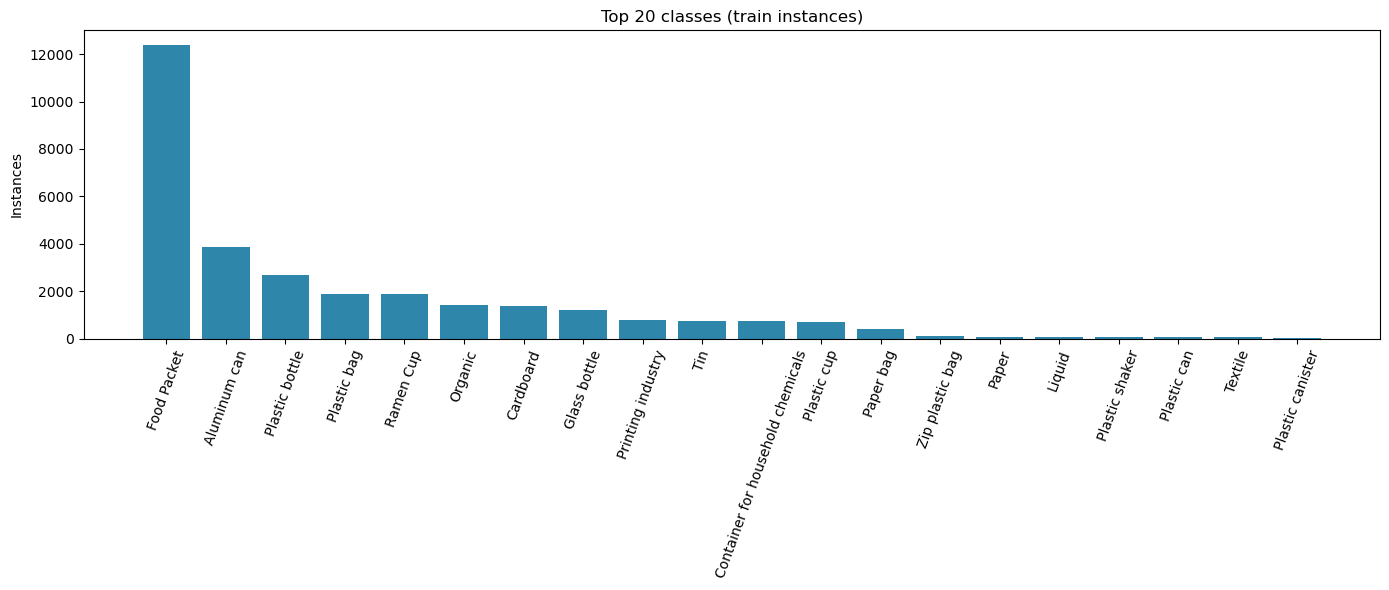

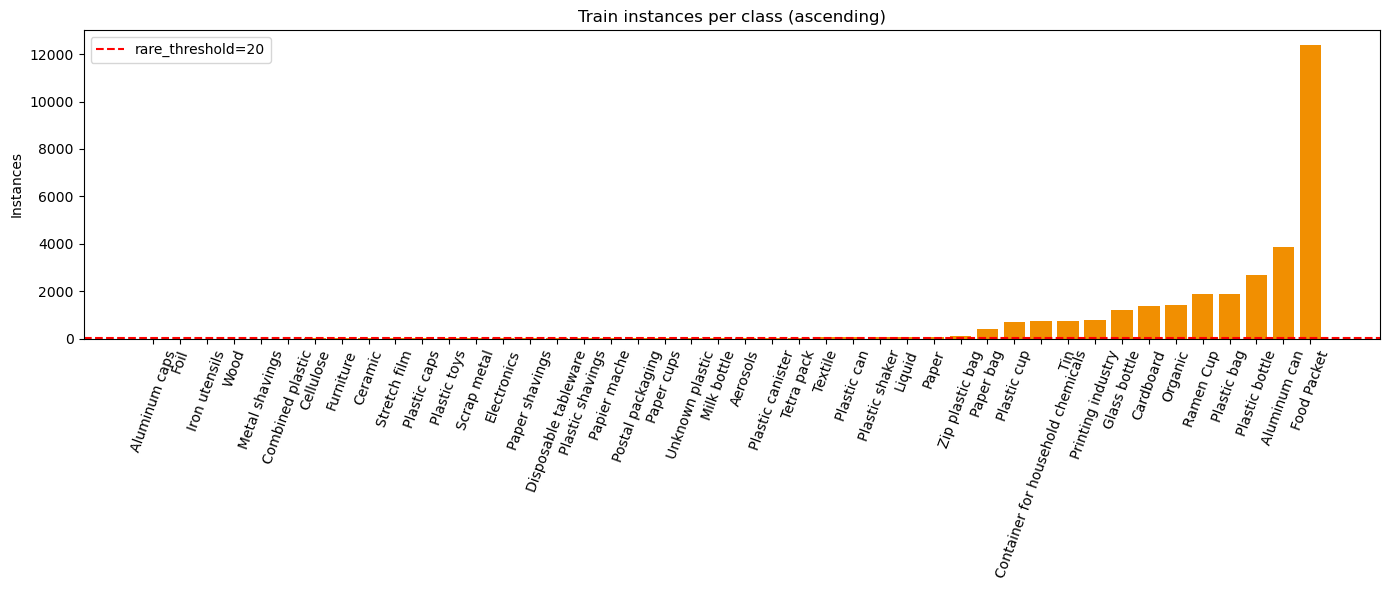

In [ ]:
audit_dir = Path('/home/antoine/utbm/wall_e_train/runs/detect/dataset_audit')
summary_csv = audit_dir / 'class_distribution_summary.csv'

# Force matplotlib inline rendering in notebook environments
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

if not summary_csv.exists():
    print(f'CSV introuvable: {summary_csv}')
else:
    df = pd.read_csv(summary_csv)
    if 'train_instances' not in df.columns or 'class_name' not in df.columns:
        raise ValueError('Colonnes attendues absentes dans class_distribution_summary.csv')

    # Graphique 1: top 20 classes par nombre d instances train
    top_df = df.sort_values('train_instances', ascending=False).head(20)
    fig1, ax1 = plt.subplots(figsize=(14, 6))
    ax1.bar(top_df['class_name'], top_df['train_instances'], color='#2E86AB')
    ax1.set_title('Top 20 classes (train instances)')
    ax1.set_ylabel('Instances')
    ax1.tick_params(axis='x', rotation=70)
    fig1.tight_layout()
    display(fig1)

    # Graphique 2: toutes les classes en ordre croissant
    asc_df = df.sort_values('train_instances', ascending=True)
    fig2, ax2 = plt.subplots(figsize=(14, 6))
    ax2.bar(asc_df['class_name'], asc_df['train_instances'], color='#F18F01')
    ax2.axhline(20, color='red', linestyle='--', label='rare_threshold=20')
    ax2.set_title('Train instances per class (ascending)')
    ax2.set_ylabel('Instances')
    ax2.tick_params(axis='x', rotation=70)
    ax2.legend()
    fig2.tight_layout()
    display(fig2)

    # Optional: avoid duplicate textual figure repr in some environments
    plt.close(fig1)
    plt.close(fig2)

## 4) Nettoyage et consolidation des classes

On retire certaines classes, fusionne d’autres, puis reconstruit un dataset propre avec un nouveau `data_clean.yaml`.

### Construction du dataset nettoyé

Applique les règles métier de suppression/fusion de classes et réécrit les labels au nouveau format.

In [ ]:
src_root = Path('/home/antoine/utbm/wall_e_train/dataset/YOLO-Waste-Detection-1/YOLO-Waste-Detection-1')
dst_root = Path('/home/antoine/utbm/wall_e_train/dataset/dataset_clean_v1')

DROP_CLASS_NAMES = {
    'Aluminum caps',
    'Metal shavings',
    'Iron utensils',
    'Plastic shaker',
    'Plastic shavings',
    'Postal packaging',
    'Wood',
    'Papier mache'
}

MERGE_TO = {
    'Aluminum can': 'Tin',
    'Plastic can': 'Plastic bottle',
    'Plastic canister': 'Plastic bottle',
    'Plastic caps': 'Plastic bottle',
    'Zip plastic bag': 'Plastic bag',
    'Paper shavings': 'Paper',
    'Paper cups': 'Paper',
    'Unknown plastic': 'Plastic bottle'
}

# Original classes (must match the YAML used during labeling)
orig_names = [
    'Aerosols', 'Aluminum can', 'Aluminum caps', 'Cardboard', 'Cellulose',
    'Ceramic', 'Combined plastic', 'Container for household chemicals',
    'Disposable tableware', 'Electronics', 'Foil', 'Furniture', 'Glass bottle',
    'Iron utensils', 'Liquid', 'Metal shavings', 'Milk bottle', 'Organic',
    'Paper bag', 'Paper cups', 'Paper shavings', 'Paper', 'Papier mache',
    'Plastic bag', 'Plastic bottle', 'Plastic can', 'Plastic canister',
    'Plastic caps', 'Plastic cup', 'Plastic shaker', 'Plastic shavings',
    'Plastic toys', 'Postal packaging', 'Printing industry', 'Scrap metal',
    'Stretch film', 'Tetra pack', 'Textile', 'Tin', 'Unknown plastic',
    'Wood', 'Zip plastic bag', 'Ramen Cup', 'Food Packet'
]

name_to_id = {n: i for i, n in enumerate(orig_names)}

# Build destination class list after drop/merge
mapped_name_set = []
for n in orig_names:
    if n in DROP_CLASS_NAMES:
        continue
    target = MERGE_TO.get(n, n)
    if target not in mapped_name_set:
        mapped_name_set.append(target)

new_names = mapped_name_set
new_name_to_id = {n: i for i, n in enumerate(new_names)}

# Mapping old class id -> new class id (or None if dropped)
id_map = {}
for old_name, old_id in name_to_id.items():
    if old_name in DROP_CLASS_NAMES:
        id_map[old_id] = None
        continue
    target_name = MERGE_TO.get(old_name, old_name)
    id_map[old_id] = new_name_to_id[target_name]

print('=== Dataset cleaning plan ===')
print(f'Original classes: {len(orig_names)}')
print(f'New classes: {len(new_names)}')
print('Dropped classes:', sorted(DROP_CLASS_NAMES))
print('Merge rules:')
for k, v in MERGE_TO.items():
    print(f'  - {k} -> {v}')

# Recreate destination tree
if dst_root.exists():
    shutil.rmtree(dst_root)

for split in ['train', 'valid', 'test']:
    (dst_root / split / 'images').mkdir(parents=True, exist_ok=True)
    (dst_root / split / 'labels').mkdir(parents=True, exist_ok=True)

stats = defaultdict(int)

for split in ['train', 'valid', 'test']:
    src_img_dir = src_root / split / 'images'
    src_lbl_dir = src_root / split / 'labels'
    dst_img_dir = dst_root / split / 'images'
    dst_lbl_dir = dst_root / split / 'labels'

    for lbl_file in src_lbl_dir.glob('*.txt'):
        stem = lbl_file.stem

        # Try to find image with common extensions
        src_img = None
        for ext in ['.jpg', '.jpeg', '.png', '.webp', '.bmp']:
            candidate = src_img_dir / f'{stem}{ext}'
            if candidate.exists():
                src_img = candidate
                break

        if src_img is None:
            stats['missing_image'] += 1
            continue

        new_lines = []
        with lbl_file.open('r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                try:
                    old_id = int(float(parts[0]))
                except Exception:
                    continue

                new_id = id_map.get(old_id, None)
                if new_id is None:
                    stats['dropped_boxes'] += 1
                    continue

                parts[0] = str(new_id)
                new_lines.append(' '.join(parts))
                stats['kept_boxes'] += 1

        # Keep image even if no labels: it acts as background
        shutil.copy2(src_img, dst_img_dir / src_img.name)
        stats['copied_images'] += 1

        with (dst_lbl_dir / lbl_file.name).open('w', encoding='utf-8') as out_f:
            if new_lines:
                out_f.write('\n'.join(new_lines) + '\n')
                stats['images_with_labels'] += 1
            else:
                stats['images_empty_after_clean'] += 1

# Write new YAML
new_yaml = {
    'path': str(dst_root),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': len(new_names),
    'names': new_names,
}

new_yaml_path = dst_root / 'data_clean.yaml'
with new_yaml_path.open('w', encoding='utf-8') as f:
    yaml.safe_dump(new_yaml, f, sort_keys=False, allow_unicode=False)

print('\n=== Cleaning complete ===')
for k in sorted(stats.keys()):
    print(f'{k}: {stats[k]}')
print(f'New dataset path: {dst_root}')
print(f'New data yaml: {new_yaml_path}')
print('\nNouvelles classes:')
for i, n in enumerate(new_names):
    print(f'  {i:02d} - {n}')

## 5) Préparation des ressources d’entraînement

Vérifie l’état GPU/CPU et vide le cache CUDA avant l’entraînement.

### Vérification mémoire et clear cache

Affiche les ressources disponibles et libère la mémoire GPU si nécessaire.

In [1]:
# Check GPU memory and system resources
print("=== GPU & System Status ===")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "N/A")
print(f"GPU Memory Allocated: {torch.cuda.memory_allocated(0) / 1e9:.1f} GB" if torch.cuda.is_available() else "N/A")
print(f"GPU Memory Reserved: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB" if torch.cuda.is_available() else "N/A")
print(f"CPU Memory Available: {psutil.virtual_memory().available / 1e9:.1f} GB")
print(f"CPU Memory Used: {psutil.virtual_memory().percent}%")

# Clear cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("\nGPU cache cleared.")

=== GPU & System Status ===
GPU Available: True
GPU Name: NVIDIA GeForce RTX 5070 Ti
GPU Memory: 17.1 GB
GPU Memory Allocated: 0.0 GB
GPU Memory Reserved: 0.0 GB
CPU Memory Available: 13.5 GB
CPU Memory Used: 19.1%

GPU cache cleared.


## 6) Entraînement des modèles

Cette section lance les entraînements YOLO (from scratch puis fine-tuning).

### Entraînement from scratch sur dataset nettoyé

Entraîne un nouveau modèle à partir de `yolo26n.pt` sur `data_clean.yaml`, avec fallback automatique en cas d’erreur mémoire.

In [2]:
cpu_count = os.cpu_count() or 8
is_wsl = 'microsoft' in os.uname().release.lower()
workers = 2 if is_wsl else min(8, max(4, cpu_count // 2))

clean_data_yaml = '/home/antoine/utbm/wall_e_train/dataset/dataset_clean_v1/data_clean.yaml'
runs_dir = Path('/home/antoine/utbm/wall_e_train/runs/detect')
run_name = 'modele_dechets_nano_scratch_clean_v1'

train_scratch_kwargs = {
    'data': clean_data_yaml,
    'epochs': 120,
    'imgsz': 640,
    'batch': 8,
    'name': run_name,
    'device': 0,
    'workers': workers,
    'patience': 30,
    'cache': 'disk',
    'amp': True,
    'optimizer': 'auto',
    'cos_lr': True,
    'close_mosaic': 10,
    'save': True,
    'plots': True,
    'verbose': True,
    'exist_ok': True
}

print('=== TRAINING FROM SCRATCH (CLEAN DATASET) ===')
print(f"Data YAML: {clean_data_yaml}")
print(f"Run name: {run_name}")
print(f"WSL detected: {is_wsl}")
print(f"Workers: {workers}")
print(f"GPU available: {torch.cuda.is_available()}")
print('Optimizer: auto (recommended for scratch)')

if not Path(clean_data_yaml).exists():
    print('Erreur: data_clean.yaml introuvable. Execute la cellule de nettoyage du dataset avant cette cellule.')
else:
    try:
        model = YOLO('yolo26n.pt')
        results = model.train(**train_scratch_kwargs)
        print('\nTraining from scratch termine.')
        print(f"Best weights: {runs_dir / run_name / 'weights' / 'best.pt'}")
    except RuntimeError as e:
        print(f"RuntimeError: {e}")
        print('Tentative fallback: imgsz=512, batch=4, workers=0')

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        fallback_kwargs = train_scratch_kwargs.copy()
        fallback_kwargs.update({
            'imgsz': 512,
            'batch': 4,
            'workers': 0,
            'name': run_name + '_fallback'
        })

        model = YOLO('yolo26n.pt')
        results = model.train(**fallback_kwargs)
        print('\nTraining from scratch termine avec fallback.')
    except Exception as e:
        print(f"Erreur inattendue: {type(e).__name__}: {e}")

=== TRAINING FROM SCRATCH (CLEAN DATASET) ===
Data YAML: /home/antoine/utbm/wall_e_train/dataset/dataset_clean_v1/data_clean.yaml
Run name: modele_dechets_nano_scratch_clean_v1
WSL detected: True
Workers: 2
GPU available: True
Optimizer: auto (recommended for scratch)
New https://pypi.org/project/ultralytics/8.4.27 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.25 🚀 Python-3.10.19 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/antoine/utbm/wall_e_train/dataset/dataset_clean_v1/data_clean.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipu

### Fine-tuning conservateur depuis un modèle existant

Relance un entraînement avec learning rate réduit pour stabiliser et affiner les performances.

In [21]:
# FINE-TUNING post-plateau depuis le modele scratch propre
cpu_count = os.cpu_count() or 8
is_wsl = 'microsoft' in os.uname().release.lower()
workers = 2 if is_wsl else min(8, max(4, cpu_count // 2))

# Dataset nettoye (meme espace de labels que le modele scratch)
clean_data_yaml = '/home/antoine/utbm/wall_e_train/dataset/dataset_clean_v1/data_clean.yaml'
runs_dir = Path('/home/antoine/utbm/wall_e_train/runs/detect')

# Base: modele entraine from scratch sur dataset clean
base_run = 'modele_dechets_nano_scratch_clean_v1'
base_path = runs_dir / base_run / 'weights' / 'best.pt'

# Fine-tuning conservateur pour depasser un plateau sans casser les acquis
finetune_run_name = 'modele_dechets_nano_finetuned_from_scratch_clean_v2'
finetune_kwargs = {
    'data': clean_data_yaml,
    'epochs': 60,
    'imgsz': 640,
    'batch': 8,
    'name': finetune_run_name,
    'device': 0,
    'workers': workers,
    'patience': 20,
    'cache': 'disk',
    'amp': True,
    'optimizer': 'sgd',
    'lr0': 0.0005,
    'lrf': 0.0005,
    'momentum': 0.9,
    'weight_decay': 0.0005,
    'warmup_epochs': 2,
    'freeze': 10,
    'cos_lr': True,
    'close_mosaic': 10,
    'save': True,
    'plots': True,
    'verbose': True,
    'exist_ok': True
}

print('=== FINE-TUNING DEPUIS MODELE SCRATCH CLEAN (POST-PLATEAU) ===')
print(f"Base model: {base_path}")
print(f"Data YAML: {clean_data_yaml}")
print(f"Run name: {finetune_run_name}")
print('Optimizer: sgd')
print(f"LR initial/final: {finetune_kwargs['lr0']}")
print(f"Patience: {finetune_kwargs['patience']}")
print(f"Freeze layers: {finetune_kwargs['freeze']}")

if not Path(clean_data_yaml).exists():
    print(f"Erreur: data yaml introuvable -> {clean_data_yaml}")
elif not base_path.exists():
    print(f"Erreur: base model introuvable -> {base_path}")
else:
    try:
        model = YOLO(str(base_path))
        results = model.train(**finetune_kwargs)
        print('\nFine-tuning termine.')
        print(f"Best weights: {runs_dir / finetune_run_name / 'weights' / 'best.pt'}")
    except RuntimeError as e:
        print(f"RuntimeError: {e}")
        print('Tentative fallback: batch=4, workers=0, freeze=12')

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        fallback_kwargs = finetune_kwargs.copy()
        fallback_kwargs.update({
            'batch': 4,
            'workers': 0,
            'freeze': 12,
            'name': finetune_run_name + '_fallback'
        })

        model = YOLO(str(base_path))
        results = model.train(**fallback_kwargs)
        print('\nFine-tuning termine avec fallback.')
        print(f"Best weights: {runs_dir / fallback_kwargs['name'] / 'weights' / 'best.pt'}")
    except Exception as e:
        print(f"Erreur: {type(e).__name__}: {e}")

=== FINE-TUNING DEPUIS MODELE SCRATCH CLEAN (POST-PLATEAU) ===
Base model: /home/antoine/utbm/wall_e_train/runs/detect/modele_dechets_nano_scratch_clean_v1/weights/best.pt
Data YAML: /home/antoine/utbm/wall_e_train/dataset/dataset_clean_v1/data_clean.yaml
Run name: modele_dechets_nano_finetuned_from_scratch_clean_v2
Optimizer: sgd
LR initial/final: 0.0005
Patience: 20
Freeze layers: 10
New https://pypi.org/project/ultralytics/8.4.30 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.25 🚀 Python-3.10.19 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/antoine/utbm/wall_e_train/dataset/dataset_clean_v1/data_clean.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dn

## 7) Analyse des résultats

On inspecte les runs récents puis on compare quantitativement les modèles.

### Inspection rapide du dernier run

Affiche les runs récents et vérifie la présence des artefacts clés (`results.csv`, courbes, poids).

In [ ]:
# List all completed training runs
runs_dir = Path('/home/antoine/utbm/wall_e_train/runs/detect')
if runs_dir.exists():
    runs = sorted([d for d in runs_dir.iterdir() if d.is_dir()], key=lambda x: x.stat().st_mtime, reverse=True)
    print("Available trained models:")
    for i, run in enumerate(runs[:5]):  # Show last 5
        print(f"  {i+1}. {run.name}")
    
    # Show results of latest training
    if runs:
        latest_run = runs[0]
        results_csv = latest_run / 'results.csv'
        
        if results_csv.exists():
            print(f"\n📊 Latest Training: {latest_run.name}")
            print(f"Results file: {results_csv}")
            
            # Display training curves if available
            for plot_file in ['results.png', 'confusion_matrix.png', 'F1_curve.png']:
                plot_path = latest_run / plot_file
                if plot_path.exists():
                    print(f"✓ {plot_file} available")
        
        # Check for best weights
        weights_dir = latest_run / 'weights'
        if weights_dir.exists():
            best_pt = weights_dir / 'best.pt'
            last_pt = weights_dir / 'last.pt'
            print(f"\n💾 Saved Weights:")
            if best_pt.exists():
                print(f"✓ Best model: {best_pt}")
            if last_pt.exists():
                print(f"✓ Last checkpoint: {last_pt}")

Available trained models:
  1. modele_dechets_nano_finetuned_from_scratch_clean_v2
  2. modele_dechets_nano_scratch_clean_v1
  3. dataset_audit
  4. modele_dechets_nano_finetuned_v2
  5. modele_dechets_nano_optim

📊 Latest Training: modele_dechets_nano_finetuned_from_scratch_clean_v2
Results file: /home/antoine/utbm/wall_e_train/runs/detect/modele_dechets_nano_finetuned_from_scratch_clean_v2/results.csv
✓ results.png available
✓ confusion_matrix.png available

💾 Saved Weights:
✓ Best model: /home/antoine/utbm/wall_e_train/runs/detect/modele_dechets_nano_finetuned_from_scratch_clean_v2/weights/best.pt
✓ Last checkpoint: /home/antoine/utbm/wall_e_train/runs/detect/modele_dechets_nano_finetuned_from_scratch_clean_v2/weights/last.pt


### Comparaison de modèles

Compare les métriques principales entre deux runs et génère une visualisation de synthèse.


MODEL COMPARISON TABLE
                                              Model  Best Epoch Precision Recall  mAP50 mAP50-95 Final Loss
modele_dechets_nano_finetuned_from_scratch_clean_v2          38    0.6692 0.5719 0.6058   0.4509     1.1618
               modele_dechets_nano_scratch_clean_v1          41    0.6355 0.5384 0.5948   0.4334     1.1588


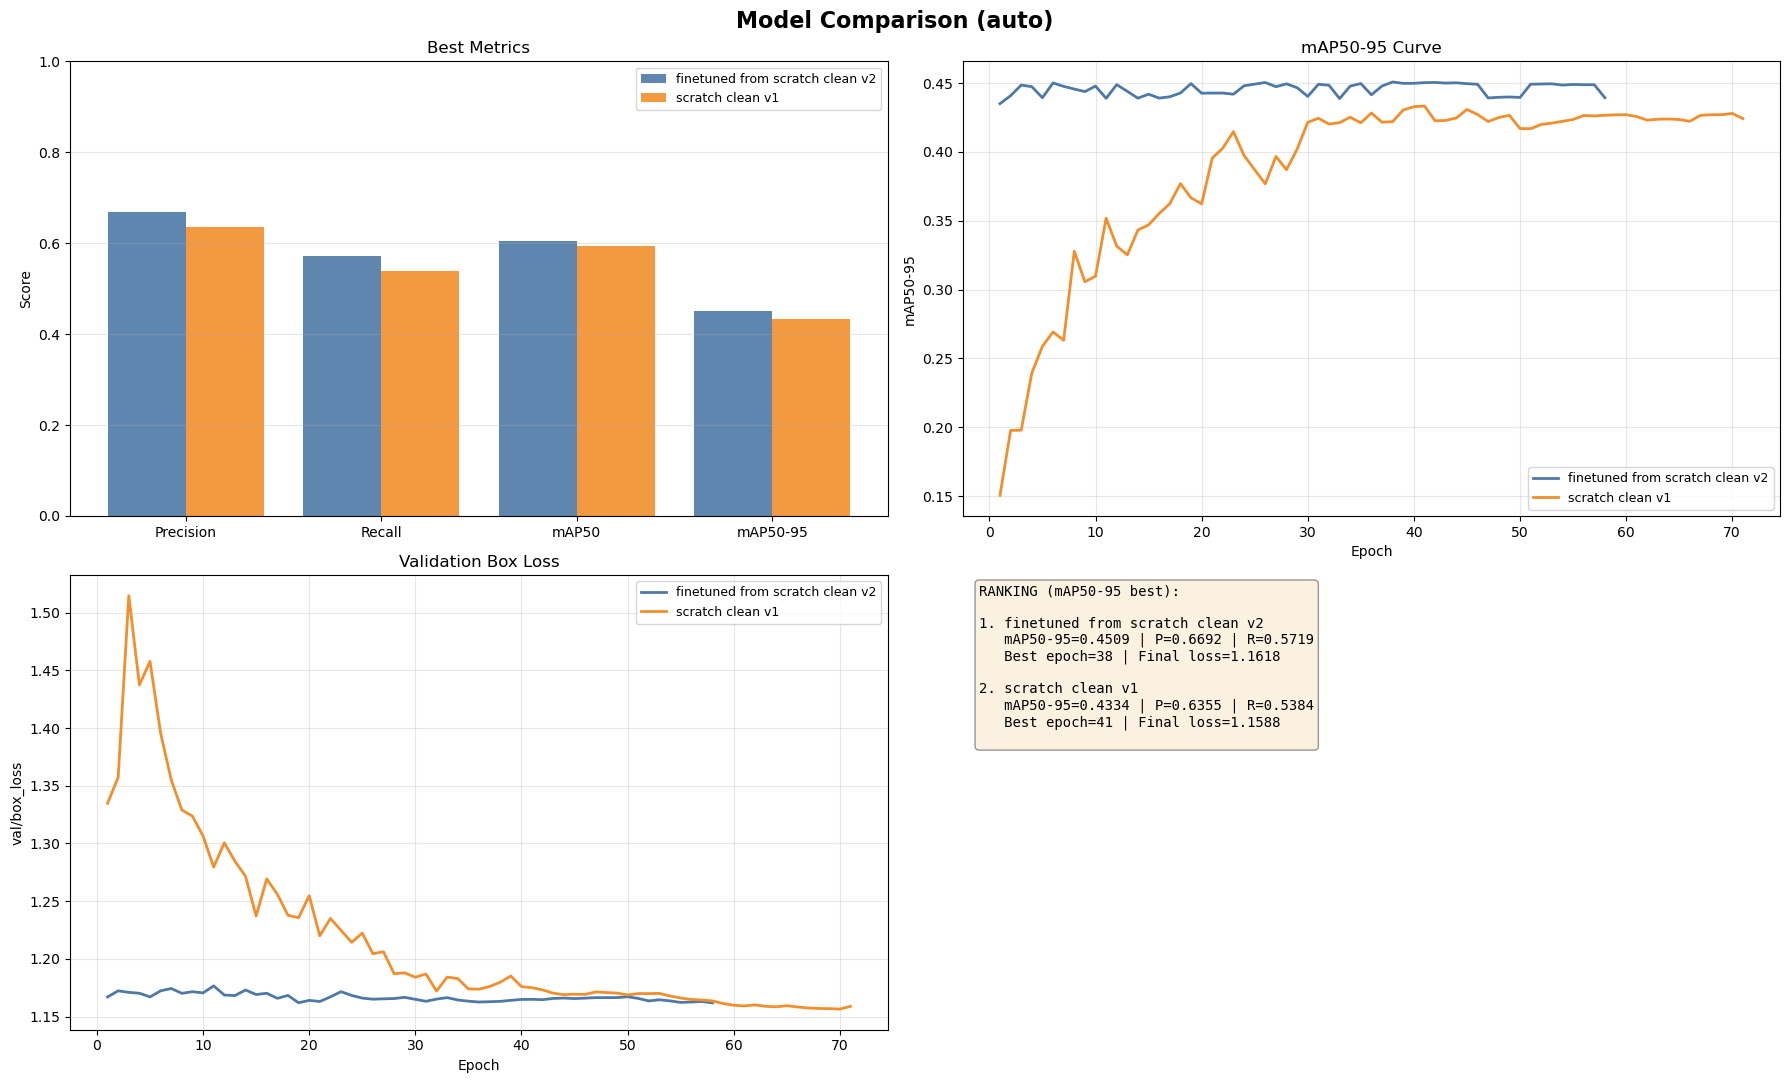


Summary:
  Best model: modele_dechets_nano_finetuned_from_scratch_clean_v2
  Margin vs 2nd: +1.74 points mAP50-95
Comparison image saved: /home/antoine/utbm/wall_e_train/reports/comparison_modele_dechets_nano_finetuned_from_scratch_clean_v2_vs_modele_dechets_nano_scratch_clean_v1_20260326_214130.png
Comparison report saved: /home/antoine/utbm/wall_e_train/reports/comparison_modele_dechets_nano_finetuned_from_scratch_clean_v2_vs_modele_dechets_nano_scratch_clean_v1_20260326_214130.md


In [ ]:
# Compare models (2 a 4 max)
runs_dir = Path('/home/antoine/utbm/wall_e_train/runs/detect')
reports_dir = Path('/home/antoine/utbm/wall_e_train/reports')
reports_dir.mkdir(parents=True, exist_ok=True)

# Modifie cette liste selon tes besoins (max 4)
models_to_compare = [
    'modele_dechets_nano_scratch_clean_v1',
    'modele_dechets_nano_finetuned_from_scratch_clean_v2',
    # 'modele_dechets_nano_clean_v2_on_merged_taco_v1',
    # 'modele_dechets_nano_reduced2',
]

# Dedup + limite a 4
models_to_compare = list(dict.fromkeys(models_to_compare))[:4]

if len(models_to_compare) < 2:
    print('Ajoute au moins 2 modeles dans models_to_compare.')
else:
    results = []
    training_data = {}

    for model_name in models_to_compare:
        model_path = runs_dir / model_name
        results_csv = model_path / 'results.csv'

        if not results_csv.exists():
            print(f'Skipped (results.csv introuvable): {model_name}')
            continue

        df = pd.read_csv(results_csv)
        if df.empty:
            print(f'Skipped (results.csv vide): {model_name}')
            continue

        needed = ['epoch', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss']
        missing = [c for c in needed if c not in df.columns]
        if missing:
            print(f'Skipped (colonnes manquantes {missing}): {model_name}')
            continue

        training_data[model_name] = df

        best_idx = df['metrics/mAP50-95(B)'].idxmax()
        best_row = df.loc[best_idx]
        last_row = df.iloc[-1]

        results.append({
            'Model': model_name,
            'Total Epochs': int(len(df) - 1),
            'Best Epoch': int(best_row['epoch']),
            'Precision (Best)': float(best_row['metrics/precision(B)']),
            'Recall (Best)': float(best_row['metrics/recall(B)']),
            'mAP50 (Best)': float(best_row['metrics/mAP50(B)']),
            'mAP50-95 (Best)': float(best_row['metrics/mAP50-95(B)']),
            'Train Time (s)': float(best_row['time']) if 'time' in df.columns else np.nan,
            'Final Loss': float(last_row['val/box_loss']),
        })

    if len(results) < 2:
        print('Pas assez de modeles valides pour comparer (minimum 2).')
    else:
        # Tri par performance globale (mAP50-95 best)
        results = sorted(results, key=lambda x: x['mAP50-95 (Best)'], reverse=True)

        # Noms courts automatiques pour les graphes
        def short_name(name: str) -> str:
            n = name
            n = n.replace('modele_dechets_nano_', '')
            n = n.replace('_', ' ')
            return n[:40]

        model_names = [r['Model'] for r in results]
        model_names_short = [short_name(m) for m in model_names]

        # Tableau console
        df_display = pd.DataFrame([
            {
                'Model': r['Model'],
                'Best Epoch': r['Best Epoch'],
                'Precision': f"{r['Precision (Best)']:.4f}",
                'Recall': f"{r['Recall (Best)']:.4f}",
                'mAP50': f"{r['mAP50 (Best)']:.4f}",
                'mAP50-95': f"{r['mAP50-95 (Best)']:.4f}",
                'Final Loss': f"{r['Final Loss']:.4f}",
            }
            for r in results
        ])

        print('\n' + '=' * 120)
        print('MODEL COMPARISON TABLE')
        print('=' * 120)
        print(df_display.to_string(index=False))
        print('=' * 120)

        # Visualisations
        fig, axes = plt.subplots(2, 2, figsize=(18, 11))
        fig.suptitle('Model Comparison (auto)', fontsize=16, fontweight='bold')

        colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2']

        # 1) Metrics comparison (grouped bars)
        ax = axes[0, 0]
        metrics = ['Precision (Best)', 'Recall (Best)', 'mAP50 (Best)', 'mAP50-95 (Best)']
        metric_labels = ['Precision', 'Recall', 'mAP50', 'mAP50-95']
        x = np.arange(len(metrics))
        n_models = len(results)
        width = 0.8 / n_models

        for i, r in enumerate(results):
            vals = [r[m] for m in metrics]
            offset = (i - (n_models - 1) / 2) * width
            ax.bar(x + offset, vals, width, label=model_names_short[i], color=colors[i % len(colors)], alpha=0.9)

        ax.set_xticks(x)
        ax.set_xticklabels(metric_labels)
        ax.set_ylim(0, 1.0)
        ax.set_ylabel('Score')
        ax.set_title('Best Metrics')
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=9)

        # 2) mAP50-95 curves
        ax = axes[0, 1]
        for i, model_name in enumerate(model_names):
            dfm = training_data[model_name]
            ax.plot(dfm['epoch'], dfm['metrics/mAP50-95(B)'], label=model_names_short[i], color=colors[i % len(colors)], linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('mAP50-95')
        ax.set_title('mAP50-95 Curve')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)

        # 3) val box loss curves
        ax = axes[1, 0]
        for i, model_name in enumerate(model_names):
            dfm = training_data[model_name]
            ax.plot(dfm['epoch'], dfm['val/box_loss'], label=model_names_short[i], color=colors[i % len(colors)], linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('val/box_loss')
        ax.set_title('Validation Box Loss')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)

        # 4) ranking summary
        ax = axes[1, 1]
        ax.axis('off')
        lines = ['RANKING (mAP50-95 best):', '']
        for i, r in enumerate(results, start=1):
            lines.append(f"{i}. {short_name(r['Model'])}")
            lines.append(f"   mAP50-95={r['mAP50-95 (Best)']:.4f} | P={r['Precision (Best)']:.4f} | R={r['Recall (Best)']:.4f}")
            lines.append(f"   Best epoch={r['Best Epoch']} | Final loss={r['Final Loss']:.4f}")
            lines.append('')

        ax.text(
            0.02,
            0.98,
            '\n'.join(lines),
            transform=ax.transAxes,
            va='top',
            fontsize=10,
            family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4),
        )

        plt.tight_layout()

        # Nom de fichier image base sur les modeles compares
        def slug(s: str) -> str:
            s = s.lower()
            s = re.sub(r'[^a-z0-9_\-]+', '-', s)
            s = re.sub(r'-+', '-', s).strip('-')
            return s

        model_slug = '_vs_'.join([slug(m) for m in model_names])
        if len(model_slug) > 140:
            model_slug = model_slug[:140]
        stamp = datetime.now().strftime('%Y%m%d_%H%M%S')

        img_path = reports_dir / f'comparison_{model_slug}_{stamp}.png'
        md_path = reports_dir / f'comparison_{model_slug}_{stamp}.md'

        plt.savefig(img_path, dpi=150, bbox_inches='tight')
        plt.show()

        # Helper sans dependance tabulate
        def dataframe_to_markdown(df_in: pd.DataFrame) -> str:
            cols = list(df_in.columns)
            header = '| ' + ' | '.join(str(c) for c in cols) + ' |'
            sep = '| ' + ' | '.join(['---'] * len(cols)) + ' |'
            rows = []
            for _, row in df_in.iterrows():
                rows.append('| ' + ' | '.join(str(row[c]) for c in cols) + ' |')
            return '\n'.join([header, sep] + rows)

        # Resume markdown dans reports
        md_lines = [
            '# Model Comparison Report',
            '',
            f'- Generated at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
            f'- Compared models ({len(model_names)}):',
        ]
        md_lines.extend([f'  - {m}' for m in model_names])
        md_lines.extend([
            '',
            '## Ranking by mAP50-95 (best)',
            '',
        ])
        for i, r in enumerate(results, start=1):
            md_lines.append(
                f"{i}. {r['Model']} | mAP50-95={r['mAP50-95 (Best)']:.4f} | Precision={r['Precision (Best)']:.4f} | Recall={r['Recall (Best)']:.4f} | Best epoch={r['Best Epoch']}"
            )
        md_lines.extend([
            '',
            '## Figure',
            '',
            f'- {img_path}',
            '',
            '## Table',
            '',
            dataframe_to_markdown(df_display),
            '',
        ])
        md_path.write_text('\n'.join(md_lines), encoding='utf-8')

        print('\nSummary:')
        if len(results) >= 2:
            best = results[0]
            second = results[1]
            delta = (best['mAP50-95 (Best)'] - second['mAP50-95 (Best)']) * 100
            print(f"  Best model: {best['Model']}")
            print(f"  Margin vs 2nd: {delta:+.2f} points mAP50-95")

        print(f'Comparison image saved: {img_path}')
        print(f'Comparison report saved: {md_path}')

## 8) Rapport final automatique

Génère une conclusion présentable avec forces/faiblesses/recommandations à partir des métriques du meilleur run disponible.

### Génération d’un rapport décisionnel

Produit un rapport texte prêt à présenter pour aider à la décision de mise en production.

In [ ]:
# === CONFIG ===
runs_dir = Path('/home/antoine/utbm/wall_e_train/runs/detect')
reports_dir = Path('/home/antoine/utbm/wall_e_train/reports')
reports_dir.mkdir(parents=True, exist_ok=True)

# Priorite: modele clean recent, sinon fallback
candidate_runs = [
    'modele_dechets_nano_finetuned_from_scratch_clean_v2',
    'modele_dechets_nano_scratch_clean_v1',
    'modele_dechets_nano_finetuned_v2',
    'modele_dechets_nano_reduced2'
]

selected_run = None
for r in candidate_runs:
    if (runs_dir / r / 'results.csv').exists():
        selected_run = r
        break

if selected_run is None:
    print('Aucun results.csv trouve dans les runs candidats.')
else:
    run_dir = runs_dir / selected_run
    results_csv = run_dir / 'results.csv'
    cm_png = run_dir / 'confusion_matrix.png'
    cm_norm_png = run_dir / 'confusion_matrix_normalized.png'
    pr_curve = run_dir / 'PR_curve.png'
    f1_curve = run_dir / 'F1_curve.png'
    p_curve = run_dir / 'P_curve.png'
    r_curve = run_dir / 'R_curve.png'
    results_png = run_dir / 'results.png'
    weights_best = run_dir / 'weights' / 'best.pt'
    weights_last = run_dir / 'weights' / 'last.pt'

    df = pd.read_csv(results_csv)
    if df.empty:
        print(f'results.csv vide: {results_csv}')
    else:
        required_cols = [
            'epoch',
            'metrics/precision(B)',
            'metrics/recall(B)',
            'metrics/mAP50(B)',
            'metrics/mAP50-95(B)',
            'val/box_loss'
        ]
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            print('Colonnes manquantes dans results.csv:')
            for c in missing:
                print(f'- {c}')
        else:
            # --- Points de reference ---
            best_idx = df['metrics/mAP50-95(B)'].idxmax()
            best = df.loc[best_idx]
            last = df.iloc[-1]
            first = df.iloc[0]

            n_epochs = len(df)
            best_epoch = int(best['epoch'])
            final_epoch = int(last['epoch'])

            p_best = float(best['metrics/precision(B)'])
            r_best = float(best['metrics/recall(B)'])
            map50_best = float(best['metrics/mAP50(B)'])
            m_best = float(best['metrics/mAP50-95(B)'])

            p_last = float(last['metrics/precision(B)'])
            r_last = float(last['metrics/recall(B)'])
            map50_last = float(last['metrics/mAP50(B)'])
            m_last = float(last['metrics/mAP50-95(B)'])
            val_loss_last = float(last['val/box_loss'])

            p_first = float(first['metrics/precision(B)'])
            r_first = float(first['metrics/recall(B)'])
            map50_first = float(first['metrics/mAP50(B)'])
            m_first = float(first['metrics/mAP50-95(B)'])

            # --- Derives et stabilite ---
            tail = df.tail(min(10, n_epochs))
            head = df.head(min(10, n_epochs))

            m_tail_mean = float(tail['metrics/mAP50-95(B)'].mean())
            m_tail_std = float(tail['metrics/mAP50-95(B)'].std(ddof=0))
            p_tail_mean = float(tail['metrics/precision(B)'].mean())
            r_tail_mean = float(tail['metrics/recall(B)'].mean())
            val_loss_tail_mean = float(tail['val/box_loss'].mean())

            m_head_mean = float(head['metrics/mAP50-95(B)'].mean())
            p_head_mean = float(head['metrics/precision(B)'].mean())
            r_head_mean = float(head['metrics/recall(B)'].mean())
            val_loss_head_mean = float(head['val/box_loss'].mean())

            # Evolution globale
            delta_map_start_end = m_last - m_first
            delta_map_best_last = m_last - m_best
            delta_p_start_end = p_last - p_first
            delta_r_start_end = r_last - r_first
            delta_map_head_tail = m_tail_mean - m_head_mean
            delta_val_loss_head_tail = val_loss_tail_mean - val_loss_head_mean

            # F1
            f1_best = (2 * p_best * r_best / (p_best + r_best)) if (p_best + r_best) > 0 else 0.0
            f1_last = (2 * p_last * r_last / (p_last + r_last)) if (p_last + r_last) > 0 else 0.0

            # Score global heuristique
            score_global = 0.45 * m_best + 0.25 * map50_best + 0.15 * p_best + 0.15 * r_best

            # --- Heuristiques d interpretation ---
            strengths = []
            weaknesses = []
            recos = []

            if m_best >= 0.55:
                strengths.append('Excellente qualite globale de detection (mAP50-95 eleve).')
            elif m_best >= 0.40:
                strengths.append('Qualite de detection globalement solide pour un systeme embarque.')
            else:
                weaknesses.append('Qualite globale encore limitee (mAP50-95 faible).')

            if p_best >= 0.75:
                strengths.append('Bonne precision: peu de faux positifs attendus.')
            elif p_best < 0.60:
                weaknesses.append('Precision insuffisante: trop de faux positifs probables.')

            if r_best >= 0.75:
                strengths.append('Bon rappel: faible risque de manquer des objets presents.')
            elif r_best < 0.60:
                weaknesses.append('Rappel insuffisant: trop d objets potentiellement manques.')

            if m_tail_std <= 0.01:
                strengths.append('Fin d entrainement stable (faible variance sur les dernieres epochs).')
            elif m_tail_std > 0.02:
                weaknesses.append('Fin d entrainement instable (fortes fluctuations des metriques).')

            if delta_map_best_last < -0.01:
                weaknesses.append('Degradation apres le meilleur epoch: signe possible de surapprentissage.')
            if best_epoch < final_epoch - 15:
                weaknesses.append('Le meilleur resultat est ancien: les epochs finales apportent peu.')

            if delta_val_loss_head_tail > 0.02 and delta_map_head_tail <= 0:
                weaknesses.append('Perte de validation en hausse sans gain de mAP: overfitting probable.')

            # Recommandations
            if r_best < 0.70:
                recos.append('Augmenter le rappel: enrichir les classes sous-representees et diversifier angles/luminosite.')
            if p_best < 0.70:
                recos.append('Augmenter la precision: nettoyer annotations ambiguës et verifier etiquetage inter-classes.')
            if m_tail_std > 0.015:
                recos.append('Stabiliser l apprentissage: diminuer legerement lr0 ou renforcer regularisation/augmentation.')
            if delta_map_best_last < -0.01:
                recos.append('Activer/renforcer early stopping et conserver strictement best.pt pour inference.')

            recos.append('Analyser la matrice de confusion normalisee pour cibler les classes a fusionner/separer.')
            recos.append('Valider sur un jeu terrain reel (camera robot, vitesses, lumieres, occlusions).')
            recos.append('Comparer la performance par classe critique avant tout deploiement en production.')

            artifacts = {
                'results.csv': results_csv.exists(),
                'results.png': results_png.exists(),
                'confusion_matrix.png': cm_png.exists(),
                'confusion_matrix_normalized.png': cm_norm_png.exists(),
                'PR_curve.png': pr_curve.exists(),
                'F1_curve.png': f1_curve.exists(),
                'P_curve.png': p_curve.exists(),
                'R_curve.png': r_curve.exists(),
                'weights/best.pt': weights_best.exists(),
                'weights/last.pt': weights_last.exists(),
            }

            level = 'elevee' if score_global >= 0.65 else ('intermediaire' if score_global >= 0.45 else 'a renforcer')

            # --- Rapport Markdown ---
            generated_at = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

            report_lines = [
                '# Rapport automatique YOLO',
                '',
                f'- Date de generation: {generated_at}',
                f'- Modele evalue: {selected_run}',
                f'- Dossier du run: {run_dir}',
                f'- Fichier source: {results_csv}',
                '',
                '## 1. Synthese executive',
                '',
                f'Le modele presente un niveau global **{level}** pour le tri robotise. Le meilleur compromis est obtenu a l epoch **{best_epoch}** (sur {final_epoch}).',
                f'Le score global heuristique est **{score_global:.4f}**.',
                '',
                '## 2. Metriques principales',
                '',
                '| Mesure | Debut | Meilleur | Fin |',
                '|---|---:|---:|---:|',
                f'| Precision | {p_first:.4f} | {p_best:.4f} | {p_last:.4f} |',
                f'| Recall | {r_first:.4f} | {r_best:.4f} | {r_last:.4f} |',
                f'| mAP50 | {map50_first:.4f} | {map50_best:.4f} | {map50_last:.4f} |',
                f'| mAP50-95 | {m_first:.4f} | {m_best:.4f} | {m_last:.4f} |',
                f'| F1 (approx) | n/a | {f1_best:.4f} | {f1_last:.4f} |',
                '',
                '## 3. Dynamique d entrainement',
                '',
                f'- Delta mAP50-95 debut -> fin: {delta_map_start_end:+.4f}',
                f'- Delta mAP50-95 best -> fin: {delta_map_best_last:+.4f}',
                f'- Delta precision debut -> fin: {delta_p_start_end:+.4f}',
                f'- Delta recall debut -> fin: {delta_r_start_end:+.4f}',
                f'- mAP50-95 moyenne (10 premieres): {m_head_mean:.4f}',
                f'- mAP50-95 moyenne (10 dernieres): {m_tail_mean:.4f}',
                f'- Delta mAP50-95 (head -> tail): {delta_map_head_tail:+.4f}',
                f'- mAP50-95 std (10 dernieres): {m_tail_std:.4f}',
                f'- val/box_loss moyenne (10 premieres): {val_loss_head_mean:.4f}',
                f'- val/box_loss moyenne (10 dernieres): {val_loss_tail_mean:.4f}',
                f'- Delta val/box_loss (head -> tail): {delta_val_loss_head_tail:+.4f}',
                '',
                '## 4. Stabilité et risque d overfitting',
                '',
                f'- Epoch optimale: {best_epoch}/{final_epoch}',
                f'- Ecart best -> last (mAP50-95): {delta_map_best_last:+.4f}',
                f'- Stabilité fin d entrainement (std mAP50-95): {m_tail_std:.4f}',
                '',
                '## 5. Artefacts disponibles',
                '',
            ]

            for k, v in artifacts.items():
                report_lines.append(f"- {k}: {'OK' if v else 'MANQUANT'}")

            report_lines.extend([
                '',
                '## 6. Forces',
                ''
            ])

            if strengths:
                report_lines.extend([f'- {s}' for s in strengths])
            else:
                report_lines.append('- Aucune force marquee detectee automatiquement.')

            report_lines.extend([
                '',
                '## 7. Faiblesses',
                ''
            ])

            if weaknesses:
                report_lines.extend([f'- {w}' for w in weaknesses])
            else:
                report_lines.append('- Pas de faiblesse majeure detectee automatiquement.')

            report_lines.extend([
                '',
                '## 8. Recommandations prioritaires',
                ''
            ])
            report_lines.extend([f'- {r}' for r in recos])

            report_lines.extend([
                '',
                '## 9. Conclusion',
                '',
                f'Le modele **{selected_run}** est exploitable a un niveau **{level}** pour un usage de tri robotise, sous reserve d une validation terrain ciblee.',
                f'Les metriques clefs au meilleur epoch sont: mAP50-95={m_best:.3f}, Precision={p_best:.3f}, Recall={r_best:.3f}.',
                'Une decision de deploiement doit integrer les erreurs de confusion par classe critique et un test en conditions reelles.',
                ''
            ])

            report_md = '\n'.join(report_lines)

            # Nom horodate + suffixe anti-collision (sans suppression des anciens)
            stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            base_name = f'report_{selected_run}_{stamp}'
            report_path = reports_dir / f'{base_name}.md'
            idx = 1
            while report_path.exists():
                report_path = reports_dir / f'{base_name}_{idx:02d}.md'
                idx += 1

            report_path.write_text(report_md, encoding='utf-8')

            # Affichage console
            print('==================== RAPPORT FINAL AUTOMATIQUE ====================')
            print(f'Modele evalue: {selected_run}')
            print(f'Score global: {score_global:.4f} | Niveau: {level}')
            print(f'Epoch optimal: {best_epoch}/{final_epoch}')
            print(f'mAP50-95 (best/last): {m_best:.4f} / {m_last:.4f}')
            print(f'Precision (best): {p_best:.4f} | Recall (best): {r_best:.4f}')
            print(f'Rapport markdown enregistre: {report_path}')
            print('===================================================================')

==================== RAPPORT FINAL AUTOMATIQUE ====================
Modele evalue: modele_dechets_nano_finetuned_from_scratch_clean_v2
Score global: 0.5405 | Niveau: intermediaire
Epoch optimal: 38/58
mAP50-95 (best/last): 0.4509 / 0.4394
Precision (best): 0.6692 | Recall (best): 0.5719
Rapport markdown enregistre: /home/antoine/utbm/wall_e_train/reports/report_modele_dechets_nano_finetuned_from_scratch_clean_v2_20260326_213429.md
